# Project 3 — Chronic Disease Cost Modelling
## Notebook 4: Predictive Model

**Author:** Amr Thabet  
**Dataset:** chronic_disease_cohort.csv — 3,000 members, 2023–2024  

### Objective
Build a machine learning model to predict which members are likely to become 
high-cost (top 20% of spend) in the following year.

Early identification of high-risk members allows UAE insurers and care management 
teams to intervene before costs escalate — the core ROI of predictive analytics 
in health insurance.

### Models
- Logistic Regression (baseline)
- Random Forest (primary model)

### Target variable
`high_cost_flag` — 1 if member is in top 20% of total cost, 0 otherwise

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Project palette
NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'

plt.rcParams.update({
    'figure.facecolor':  LIGHT_BG,
    'axes.facecolor':    LIGHT_BG,
    'axes.edgecolor':    GRAY,
    'axes.labelcolor':   NAVY,
    'axes.titlepad':     14,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   NAVY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'text.color':        NAVY,
    'grid.color':        '#D8E4E8',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
})

df = pd.read_csv('../data/chronic_disease_cohort.csv')
print(f"Loaded {len(df):,} members · {df.shape[1]} columns")
print(f"High-cost members: {df['high_cost_flag'].sum():,} ({df['high_cost_flag'].mean()*100:.0f}%)")

Loaded 3,000 members · 25 columns
High-cost members: 600 (20%)


## Step 1 — Feature engineering and train/test split

Selecting the clinical and utilisation features that will be used to predict
high-cost membership. Categorical variables are encoded and the dataset is
split 80/20 into training and test sets.

In [27]:
# Feature selection
features = ['age', 'bmi', 'systolic_bp', 'smoker', 'comorbidities',
            'er_visits', 'inpatient_days', 'outpatient_visits',
            'specialist_visits', 'condition', 'plan_tier',
            'medication_compliance', 'nationality', 'emirate']

target = 'high_cost_flag'

df_model = df[features + [target]].copy()

# Encode categoricals
le = LabelEncoder()
for col in ['condition', 'plan_tier', 'medication_compliance', 'nationality', 'emirate']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set:  {X_train.shape[0]:,} members")
print(f"Test set:      {X_test.shape[0]:,} members")
print(f"High-cost in test set: {y_test.sum():,} ({y_test.mean()*100:.0f}%)")

Training set:  2,400 members
Test set:      600 members
High-cost in test set: 120 (20%)


## Step 2 — Logistic Regression (baseline model)

A simple, interpretable baseline. Logistic Regression is fast and explainable —
useful for communicating model logic to non-technical stakeholders.

In [28]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]
auc_lr     = roc_auc_score(y_test, y_prob_lr)

print("── Logistic Regression ──────────────────────────")
print(f"AUC-ROC: {auc_lr:.3f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_lr, target_names=['Standard', 'High cost']))

── Logistic Regression ──────────────────────────
AUC-ROC: 0.785

Classification report:
              precision    recall  f1-score   support

    Standard       0.84      0.95      0.89       480
   High cost       0.58      0.25      0.35       120

    accuracy                           0.81       600
   macro avg       0.71      0.60      0.62       600
weighted avg       0.78      0.81      0.78       600



## Step 3 — Random Forest (primary model)

Random Forest handles non-linear relationships and interactions between features
that Logistic Regression misses. It also produces feature importance scores —
telling us which clinical variables drive high-cost predictions the most.

In [29]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
auc_rf     = roc_auc_score(y_test, y_prob_rf)

print("── Random Forest ────────────────────────────────")
print(f"AUC-ROC: {auc_rf:.3f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_rf, target_names=['Standard', 'High cost']))

── Random Forest ────────────────────────────────
AUC-ROC: 0.950

Classification report:
              precision    recall  f1-score   support

    Standard       0.96      0.88      0.92       480
   High cost       0.64      0.87      0.74       120

    accuracy                           0.88       600
   macro avg       0.80      0.87      0.83       600
weighted avg       0.90      0.88      0.88       600



## Step 4 — ROC curve comparison

The ROC curve shows how well each model distinguishes high-cost from standard members
across all classification thresholds. AUC closer to 1.0 = better model.
A random classifier scores 0.5 — the dashed line below.

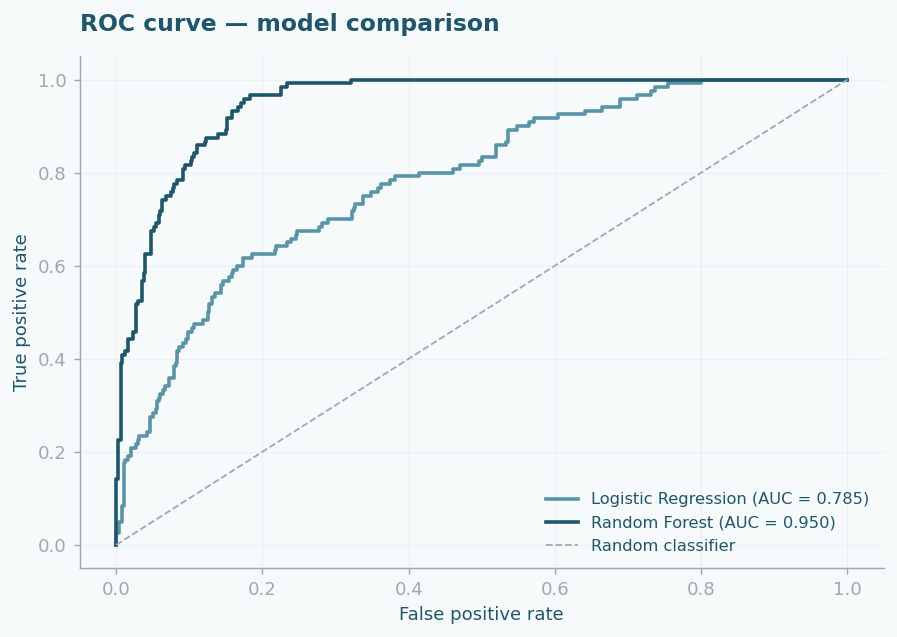

In [30]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=TEAL, linewidth=2,
        label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_rf, tpr_rf, color=NAVY, linewidth=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0,1], [0,1], color=GRAY, linewidth=1,
        linestyle='--', label='Random classifier')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve — model comparison', loc='left')
ax.legend(framealpha=0, fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/11_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Confusion matrix (Random Forest)

Shows exactly where the model is right and wrong:
- **True Positives** — correctly flagged high-cost members
- **False Negatives** — high-cost members we missed
- **False Positives** — standard members incorrectly flagged

In health insurance, False Negatives are costly — missing a high-cost member
means no early intervention. The model is tuned with `class_weight='balanced'`
to reduce this.

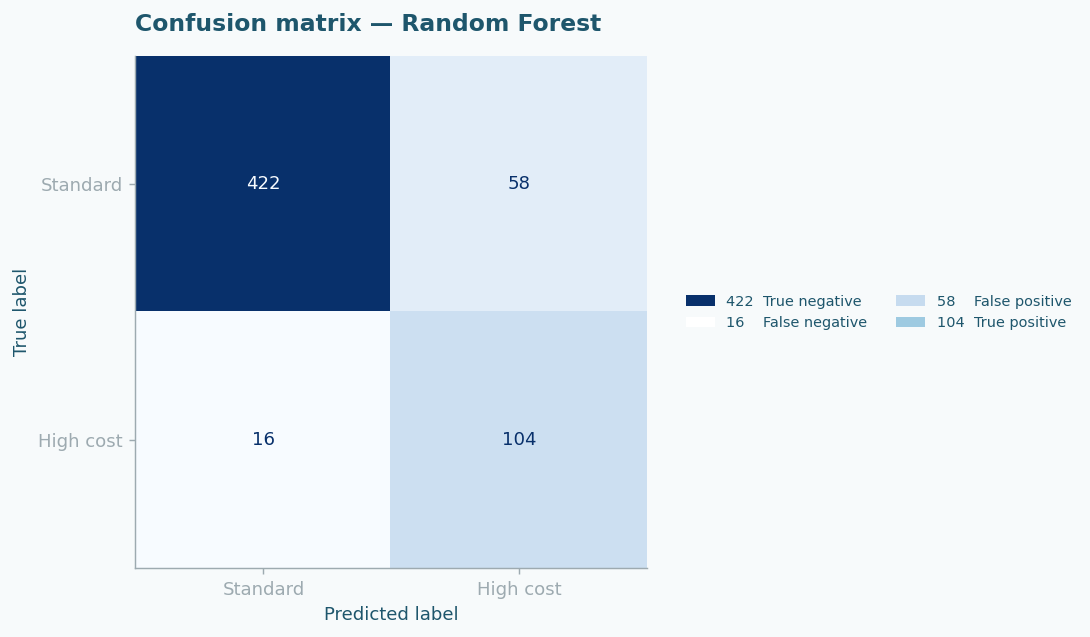

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Standard', 'High cost'])
disp.plot(ax=ax, colorbar=False, cmap=plt.cm.Blues)
ax.set_title('Confusion matrix — Random Forest', loc='left')
ax.grid(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#08306B', label='422  True negative'),
    Patch(facecolor='#FFFFFF', label='16    False negative'),
    Patch(facecolor='#C6DBEF', label='58    False positive'),
    Patch(facecolor='#9ECAE1', label='104  True positive'),
]
ax.legend(handles=legend_elements,
          loc='center left',
          bbox_to_anchor=(1.05, 0.5),
          framealpha=0,
          fontsize=8,
          ncol=2)

plt.tight_layout()
plt.savefig('../outputs/12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Feature importance (Random Forest)

Which clinical and utilisation variables drive the model's predictions the most?
This tells us where to focus care management intervention to prevent high-cost claims.

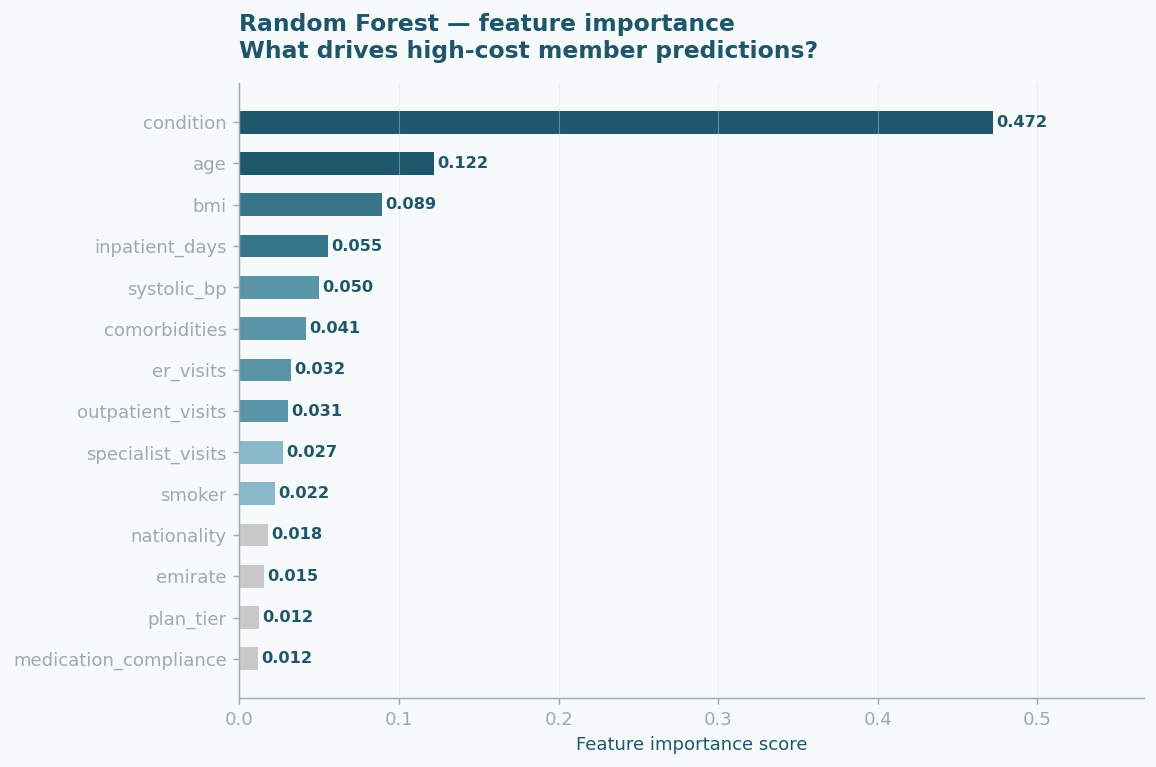

In [32]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()
n = len(importance)
grade_colors = []
for i, val in enumerate(importance.values):
    if val >= 0.1:
        grade_colors.append(NAVY)
    elif val >= 0.05:
        grade_colors.append(TEAL_DARK)
    elif val >= 0.03:
        grade_colors.append(TEAL)
    elif val >= 0.02:
        grade_colors.append(TEAL_LIGHT)
    else:
        grade_colors.append('#C8C8C8')

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance.index, importance.values,
               color=grade_colors, height=0.55, edgecolor='none')

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9,
            color=NAVY, fontweight='bold')

ax.set_xlabel('Feature importance score')
ax.set_title('Random Forest — feature importance\nWhat drives high-cost member predictions?', loc='left')
ax.set_xlim(0, importance.max() * 1.2)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Model summary and business interpretation

Key findings from the predictive model for a UAE health insurance audience.

In [33]:
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nLogistic Regression AUC:  {auc_lr:.3f}")
print(f"Random Forest AUC:        {auc_rf:.3f}")
print(f"\nRandom Forest improvement: +{(auc_rf - auc_lr):.3f} AUC points")

top_features = importance.tail(5).index.tolist()[::-1]
print(f"\nTop 5 predictors of high-cost membership:")
for i, f in enumerate(top_features, 1):
    print(f"  {i}. {f}  ({importance[f]:.3f})")

total_spend    = df['total_cost_aed'].sum()
highcost_spend = df[df['high_cost_flag']==1]['total_cost_aed'].sum()
print(f"\n80/20 check:")
print(f"  Top 20% members account for "
      f"AED {highcost_spend/1_000_000:.1f}M "
      f"({highcost_spend/total_spend*100:.1f}% of total spend)")
print(f"  Total portfolio spend: AED {total_spend/1_000_000:.1f}M")
print(f"\nIf model identifies 70% of high-cost members early:")
avg_saving_per_intervention = 8000
interventions = int(df['high_cost_flag'].sum() * 0.70)
total_saving  = interventions * avg_saving_per_intervention
print(f"  Members flagged: {interventions:,}")
print(f"  Potential saving @ AED 8,000/intervention: "
      f"AED {total_saving/1_000_000:.1f}M")
print("\nModel complete ✓")

MODEL PERFORMANCE SUMMARY

Logistic Regression AUC:  0.785
Random Forest AUC:        0.950

Random Forest improvement: +0.165 AUC points

Top 5 predictors of high-cost membership:
  1. condition  (0.472)
  2. age  (0.122)
  3. bmi  (0.089)
  4. inpatient_days  (0.055)
  5. systolic_bp  (0.050)

80/20 check:
  Top 20% members account for AED 45.2M (37.4% of total spend)
  Total portfolio spend: AED 120.8M

If model identifies 70% of high-cost members early:
  Members flagged: 420
  Potential saving @ AED 8,000/intervention: AED 3.4M

Model complete ✓
